In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import os

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
OUTPUT_FOLDER = "outputs"
VISUAL_FOLDER = "visuals"

In [6]:
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
os.makedirs(VISUAL_FOLDER, exist_ok=True)

In [7]:
file_path = (r"C:\Users\Dell\OneDrive\Documents\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [9]:
df = pd.read_csv(file_path)

In [10]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [11]:
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


In [12]:
print("\nColumn names:")


Column names:


In [13]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [14]:
print("\nData types:")
print(df.dtypes)



Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [15]:
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [16]:
print("\nFirst five records:")
print(df.head())


First five records:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies

In [17]:
df.columns = df.columns.str.strip()

In [18]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [19]:
print("\nRows with missing TotalCharges:")
print(df[df["TotalCharges"].isna()][["customerID", "tenure", "TotalCharges"]])


Rows with missing TotalCharges:
      customerID  tenure  TotalCharges
488   4472-LVYGI       0           NaN
753   3115-CZMZD       0           NaN
936   5709-LVOEQ       0           NaN
1082  4367-NUYAO       0           NaN
1340  1371-DWPAZ       0           NaN
3331  7644-OMVMY       0           NaN
3826  3213-VVOLG       0           NaN
4380  2520-SGTTA       0           NaN
5218  2923-ARZLG       0           NaN
6670  4075-WKNIU       0           NaN
6754  2775-SEFEE       0           NaN


In [20]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [21]:
df["ChurnFlag"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [22]:
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

In [23]:
df["TenureBand"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [24]:
df["MonthlyChargeBand"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

In [25]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())



Missing values after cleaning:
customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          0
Churn                 0
ChurnFlag             0
SeniorCitizenLabel    0
TenureBand            0
MonthlyChargeBand     0
dtype: int64


In [26]:
df.to_csv(
    os.path.join(OUTPUT_FOLDER, "telco_churn_clean.csv"),
    index=False
)

In [27]:
def churn_summary(data, column):
    summary = (
        data.groupby(column, dropna=False)
        .agg(
            Customers=("customerID", "count"),
            ChurnedCustomers=("ChurnFlag", "sum"),
            ChurnRate=("ChurnFlag", "mean"),
            AverageMonthlyCharge=("MonthlyCharges", "mean")
        )
        .reset_index()
    )

    summary["ChurnRate"] = (summary["ChurnRate"] * 100).round(2)
    summary["AverageMonthlyCharge"] = (
        summary["AverageMonthlyCharge"].round(2)
    )

    return summary.sort_values("ChurnRate", ascending=False)

In [28]:
total_customers = len(df)
churned_customers = df["ChurnFlag"].sum()
churn_rate = df["ChurnFlag"].mean() * 100

monthly_revenue = df["MonthlyCharges"].sum()
monthly_revenue_lost = df.loc[
    df["ChurnFlag"] == 1,
    "MonthlyCharges"
].sum()

print("\n--- Overall KPIs ---")
print("Total customers:", total_customers)
print("Churned customers:", churned_customers)
print("Churn rate:", round(churn_rate, 2), "%")
print("Total monthly revenue: $", round(monthly_revenue, 2))
print("Monthly revenue from churned customers: $", round(monthly_revenue_lost, 2))


--- Overall KPIs ---
Total customers: 7043
Churned customers: 1869
Churn rate: 26.54 %
Total monthly revenue: $ 456116.6
Monthly revenue from churned customers: $ 139130.85


In [29]:
contract_summary = churn_summary(df, "Contract")
payment_summary = churn_summary(df, "PaymentMethod")
internet_summary = churn_summary(df, "InternetService")
tenure_summary = churn_summary(df, "TenureBand")
support_summary = churn_summary(df, "TechSupport")
security_summary = churn_summary(df, "OnlineSecurity")

print("\nChurn by Contract:")
print(contract_summary)

print("\nChurn by Payment Method:")
print(payment_summary)

print("\nChurn by Tenure:")
print(tenure_summary)


Churn by Contract:
         Contract  Customers  ChurnedCustomers  ChurnRate  \
0  Month-to-month       3875              1655      42.71   
1        One year       1473               166      11.27   
2        Two year       1695                48       2.83   

   AverageMonthlyCharge  
0                 66.40  
1                 65.05  
2                 60.77  

Churn by Payment Method:
               PaymentMethod  Customers  ChurnedCustomers  ChurnRate  \
2           Electronic check       2365              1071      45.29   
3               Mailed check       1612               308      19.11   
0  Bank transfer (automatic)       1544               258      16.71   
1    Credit card (automatic)       1522               232      15.24   

   AverageMonthlyCharge  
2                 76.26  
3                 43.92  
0                 67.19  
1                 66.51  

Churn by Tenure:
     TenureBand  Customers  ChurnedCustomers  ChurnRate  AverageMonthlyCharge
0    0-6 months   

In [30]:
contract_summary.to_csv(
    os.path.join(OUTPUT_FOLDER, "churn_by_contract.csv"),
    index=False
)

payment_summary.to_csv(
    os.path.join(OUTPUT_FOLDER, "churn_by_payment_method.csv"),
    index=False
)

tenure_summary.to_csv(
    os.path.join(OUTPUT_FOLDER, "churn_by_tenure.csv"),
    index=False
)

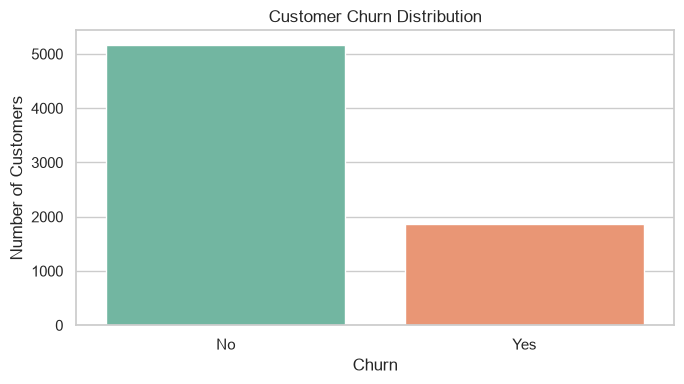

In [31]:
sns.set_theme(style="whitegrid")

# Overall churn count
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_FOLDER, "churn_distribution.png"))
plt.show()

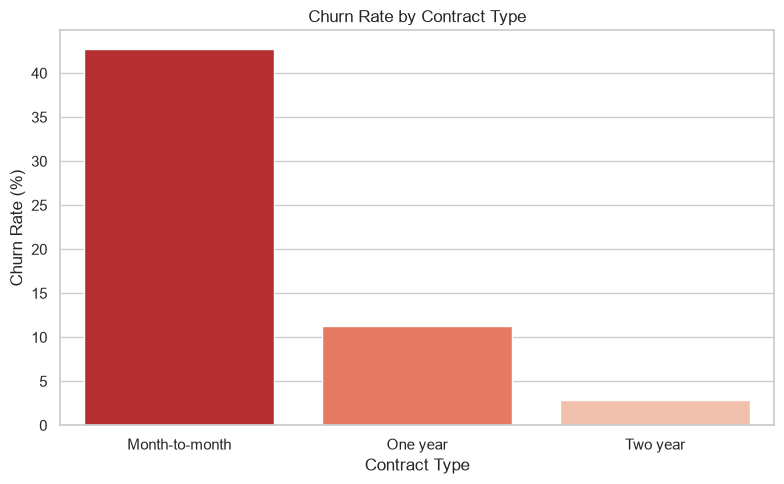

In [32]:
# Churn rate by contract type
plt.figure(figsize=(8, 5))
sns.barplot(
    data=contract_summary,
    x="Contract",
    y="ChurnRate",
    hue="Contract",
    palette="Reds_r",
    legend=False
)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_FOLDER, "churn_by_contract.png"))
plt.show()

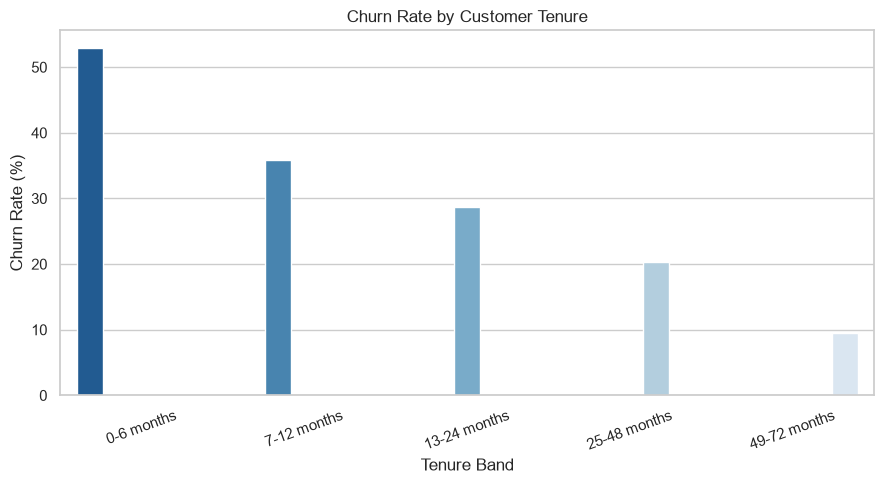

In [33]:
# Churn rate by tenure band
plt.figure(figsize=(9, 5))
sns.barplot(
    data=tenure_summary,
    x="TenureBand",
    y="ChurnRate",
    hue="TenureBand",
    palette="Blues_r",
    legend=False
)
plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Band")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_FOLDER, "churn_by_tenure.png"))
plt.show()

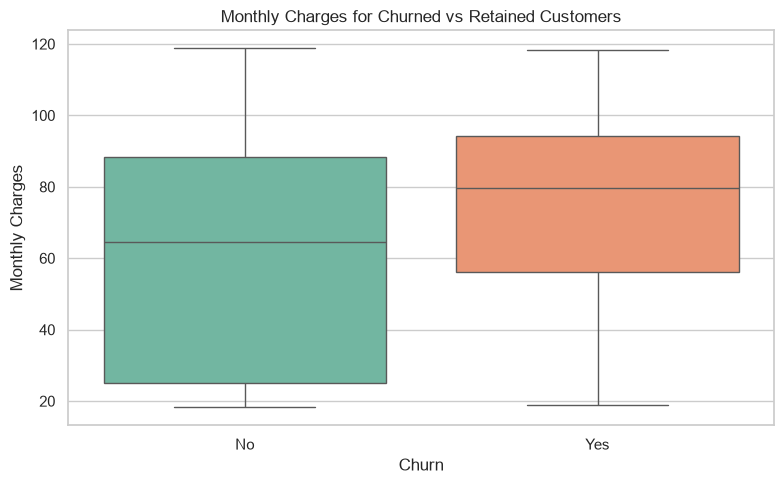

In [34]:
# Charges by churn status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", palette="Set2")
plt.title("Monthly Charges for Churned vs Retained Customers")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_FOLDER, "monthly_charges_by_churn.png"))
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import joblib

In [36]:
target = "ChurnFlag"

features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges"
]

X = df[features]
y = df[target]

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    column for column in features
    if column not in numeric_features
]

In [37]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [38]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [39]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

print("\n--- Model Results ---")
print(classification_report(y_test, predictions))
print("ROC-AUC Score:", round(roc_auc_score(y_test, probabilities), 3))


--- Model Results ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.842


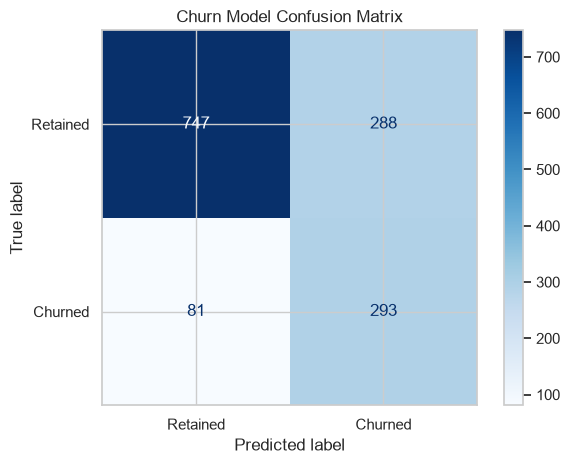

In [40]:
cm = confusion_matrix(y_test, predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Retained", "Churned"]
)

display.plot(cmap="Blues")
plt.title("Churn Model Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(VISUAL_FOLDER, "confusion_matrix.png"))
plt.show()

In [41]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.named_steps["classifier"].coef_[0]
})

coefficients["Impact"] = np.where(
    coefficients["Coefficient"] > 0,
    "Increases churn risk",
    "Reduces churn risk"
)

coefficients["AbsoluteImpact"] = coefficients["Coefficient"].abs()

important_features = coefficients.sort_values(
    "AbsoluteImpact",
    ascending=False
)

print("\nTop Churn Drivers:")
print(important_features.head(20))

important_features.to_csv(
    os.path.join(OUTPUT_FOLDER, "model_churn_drivers.csv"),
    index=False
)


Top Churn Drivers:
                                              Feature  Coefficient  \
1                                     numeric__tenure    -1.154434   
38                     categorical__Contract_Two year    -0.775518   
16           categorical__InternetService_Fiber optic     0.707981   
2                             numeric__MonthlyCharges    -0.676114   
36               categorical__Contract_Month-to-month     0.657713   
15                   categorical__InternetService_DSL    -0.622465   
3                               numeric__TotalCharges     0.489698   
28       categorical__TechSupport_No internet service    -0.275403   
25  categorical__DeviceProtection_No internet service    -0.275403   
17                    categorical__InternetService_No    -0.275403   
19    categorical__OnlineSecurity_No internet service    -0.275403   
34   categorical__StreamingMovies_No internet service    -0.275403   
31       categorical__StreamingTV_No internet service    -0.275403   


In [42]:
df["ChurnProbability"] = model.predict_proba(X)[:, 1]

df["RiskBand"] = pd.cut(
    df["ChurnProbability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

df["MonthlyRevenueAtRisk"] = np.where(
    df["RiskBand"] == "High Risk",
    df["MonthlyCharges"],
    0
)

def retention_action(row):
    if row["Contract"] == "Month-to-month":
        return "Offer annual-contract discount"
    elif row["PaymentMethod"] == "Electronic check":
        return "Promote autopay enrollment"
    elif row["TechSupport"] == "No":
        return "Offer Tech Support bundle"
    elif row["OnlineSecurity"] == "No":
        return "Offer Online Security bundle"
    elif row["tenure"] <= 6:
        return "Early-life onboarding call"
    else:
        return "Personalized retention offer"

df["RecommendedAction"] = df.apply(retention_action, axis=1)

In [43]:
retention_priority_list = (
    df[df["RiskBand"] == "High Risk"]
    .sort_values(
        by=["ChurnProbability", "MonthlyCharges"],
        ascending=[False, False]
    )
    [[
        "customerID",
        "tenure",
        "Contract",
        "PaymentMethod",
        "InternetService",
        "TechSupport",
        "OnlineSecurity",
        "MonthlyCharges",
        "ChurnProbability",
        "RiskBand",
        "RecommendedAction"
    ]]
)

retention_priority_list.to_csv(
    os.path.join(OUTPUT_FOLDER, "high_risk_customer_retention_list.csv"),
    index=False
)

print("\nHigh-risk customers:", len(retention_priority_list))
print("\nRevenue at risk: $", round(df["MonthlyRevenueAtRisk"].sum(), 2))
print(retention_priority_list.head(10))


High-risk customers: 2350

Revenue at risk: $ 183543.45
      customerID  tenure        Contract     PaymentMethod InternetService  \
1976  9497-QCMMS       1  Month-to-month  Electronic check     Fiber optic   
4800  9300-AGZNL       1  Month-to-month  Electronic check     Fiber optic   
3380  5178-LMXOP       1  Month-to-month  Electronic check     Fiber optic   
3749  4424-TKOPW       2  Month-to-month  Electronic check     Fiber optic   
6368  2720-WGKHP       2  Month-to-month  Electronic check     Fiber optic   
5989  5567-WSELE       3  Month-to-month  Electronic check     Fiber optic   
1410  7024-OHCCK       2  Month-to-month  Electronic check     Fiber optic   
3159  5150-ITWWB       3  Month-to-month  Electronic check     Fiber optic   
2208  7216-EWTRS       1  Month-to-month  Electronic check     Fiber optic   
997   1374-DMZUI       4  Month-to-month  Electronic check     Fiber optic   

     TechSupport OnlineSecurity  MonthlyCharges  ChurnProbability   RiskBand  \
1976

In [44]:
joblib.dump(
    model,
    os.path.join(OUTPUT_FOLDER, "churn_prediction_model.pkl")
)

['outputs\\churn_prediction_model.pkl']

In [46]:
mysql_df = df.rename(columns={
    "customerID": "customer_id",
    "SeniorCitizen": "senior_citizen",
    "Partner": "partner",
    "Dependents": "dependents",
    "PhoneService": "phone_service",
    "MultipleLines": "multiple_lines",
    "InternetService": "internet_service",
    "OnlineSecurity": "online_security",
    "OnlineBackup": "online_backup",
    "DeviceProtection": "device_protection",
    "TechSupport": "tech_support",
    "StreamingTV": "streaming_tv",
    "StreamingMovies": "streaming_movies",
    "Contract": "contract_type",
    "PaperlessBilling": "paperless_billing",
    "PaymentMethod": "payment_method",
    "MonthlyCharges": "monthly_charges",
    "TotalCharges": "total_charges",
    "Churn": "churn",
    "ChurnFlag": "churn_flag",
    "TenureBand": "tenure_band",
    "MonthlyChargeBand": "monthly_charge_band",
    "ChurnProbability": "churn_probability",
    "RiskBand": "risk_band",
    "MonthlyRevenueAtRisk": "monthly_revenue_at_risk",
    "RecommendedAction": "recommended_action"
})

In [47]:
mysql_columns = [
    "customer_id", "gender", "senior_citizen", "partner", "dependents",
    "tenure", "phone_service", "multiple_lines", "internet_service",
    "online_security", "online_backup", "device_protection",
    "tech_support", "streaming_tv", "streaming_movies", "contract_type",
    "paperless_billing", "payment_method", "monthly_charges",
    "total_charges", "churn", "churn_flag", "tenure_band",
    "monthly_charge_band", "churn_probability", "risk_band",
    "monthly_revenue_at_risk", "recommended_action"
]

In [48]:
missing_columns = [
    column for column in mysql_columns
    if column not in mysql_df.columns
]

print("Missing columns:", missing_columns)

Missing columns: []


In [49]:
mysql_df = mysql_df[mysql_columns]

mysql_df.to_csv(
    "outputs/telco_churn_mysql.csv",
    index=False
)

print(mysql_df.shape)
print(mysql_df.head())

(7043, 28)
  customer_id  gender  senior_citizen partner dependents  tenure  \
0  7590-VHVEG  Female               0     Yes         No       1   
1  5575-GNVDE    Male               0      No         No      34   
2  3668-QPYBK    Male               0      No         No       2   
3  7795-CFOCW    Male               0      No         No      45   
4  9237-HQITU  Female               0      No         No       2   

  phone_service    multiple_lines internet_service online_security  ...  \
0            No  No phone service              DSL              No  ...   
1           Yes                No              DSL             Yes  ...   
2           Yes                No              DSL             Yes  ...   
3            No  No phone service              DSL             Yes  ...   
4           Yes                No      Fiber optic              No  ...   

  monthly_charges total_charges churn churn_flag   tenure_band  \
0           29.85         29.85    No          0    0-6 months 